# NIFTY Gap Strategy — v2 Backtest (Real Option Candles)
**SGX signal**: NKD=F (CME Nikkei 225 futures) — previous day close-to-close return  
**Strategy**: Buy 1-OTM NIFTY PUT at 9:25 AM on bearish signal days. Exit at SL / TP / 11:15 AM.  
**Option prices**: Real 1-min candles from `merged/` (same source as DTE0_options backtest).  
**Period**: Jan 2024 – Apr 2026 (constrained by real option data availability).  

| Parameter | Value |
|-----------|-------|
| SL | −15% of entry premium |
| TP | +40% of entry premium |
| Hard exit | 11:15 AM IST |
| Strike | ATM − 50 (1-OTM PUT) |
| Lots | capital-scaled, min=5, max=25 (DTE=0 capped at 10) |
| Starting capital | Rs 2,00,000 |

SL checked against candle `low`, TP against candle `high` — realistic intrabar detection.

In [1]:
import pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import date, timedelta

warnings.filterwarnings('ignore')

# ── Parameters — match cron/v2/config.py ────────────────────────────────────
SL_PCT          = 0.15
TP_PCT          = 0.40
LOT_SIZE        = 75
STRIKE_STEP     = 50
BASE_LOTS       = 5
MAX_LOTS        = 25
DTE0_MAX_LOTS   = 10
STARTING_CAPITAL = 200_000.0
BASE_RATE       = 54.5
GAP_THR         = 0.0015
GAP_LARGE       = 0.0050
VIX_RISING_THR  = 0.03
VIX_SPIKE_THR   = 0.05

# Real option data starts Jan 2024
DATA_START = date(2024, 1, 2)

# Old/new format cutoff (expiry date decides which loader to use)
OLD_CUTOFF = date(2024, 11, 1)
_MON = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']

print('Config loaded.')

Config loaded.


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# Notebook: gap_trading/backtest-merged/ → parent=gap_trading/ → parent=market-research/
GAP_TRADING     = Path.cwd().parent
MARKET_RESEARCH = Path.cwd().parent.parent
ALIGNED_CSV     = GAP_TRADING / 'v2' / 'v2_aligned_dataset.csv'
SIGNALS_CSV     = GAP_TRADING / 'v2' / 'v2_reliable_signals.csv'
MINUTE_CACHE    = GAP_TRADING / 'kite_minute_cache'
MERGE_OLD       = MARKET_RESEARCH / 'merged' / 'old_format'
MERGE_NEW       = MARKET_RESEARCH / 'merged' / 'expiry_wise'

for lbl, p in [('Aligned CSV', ALIGNED_CSV), ('Signals CSV', SIGNALS_CSV),
               ('Minute cache', MINUTE_CACHE), ('Merge old', MERGE_OLD), ('Merge new', MERGE_NEW)]:
    print(f'{lbl:<14}: {"OK" if p.exists() else "MISSING"}  ({p})')

# Load aligned dataset — restrict to real-data period
aligned = pd.read_csv(ALIGNED_CSV, parse_dates=['india_date'])
aligned = aligned.sort_values('india_date').reset_index(drop=True)
aligned['VIX_INDIA_level'] = aligned['VIX_INDIA_level'].ffill().bfill()
aligned = aligned[aligned['india_date'].dt.date >= DATA_START].reset_index(drop=True)

# Top-10 bearish combos
reliable    = pd.read_csv(SIGNALS_CSV)
top_bearish = (reliable[reliable['P_Down'] > BASE_RATE]
               .sort_values('Edge_pp', ascending=False)
               .head(10)
               .reset_index(drop=True))
bear_combos = list(top_bearish['Signal'])

print(f'\nDataset : {aligned.india_date.min().date()} to {aligned.india_date.max().date()}  ({len(aligned)} days)')

# Build spot map: date → NIFTY spot at 09:25 (for ATM calculation)
spot_map = {}
for pkl_path in sorted(MINUTE_CACHE.glob('minute_256265_*.pkl')):
    with open(pkl_path, 'rb') as f:
        chunk = pickle.load(f)
    chunk.index = pd.to_datetime(chunk.index)
    if chunk.index.tzinfo is not None:
        chunk.index = chunk.index.tz_localize(None)
    for dt, row in chunk.iterrows():
        if dt.strftime('%H:%M') == '09:25':
            spot_map[dt.date()] = float(row['open'])

print(f'Spot map: {len(spot_map)} dates with 09:25 NIFTY level')

Aligned CSV   : OK  (c:\Users\sayan\OneDrive\Desktop\Projects\03_Market_Research\market-research\gap_trading\v2\v2_aligned_dataset.csv)
Signals CSV   : OK  (c:\Users\sayan\OneDrive\Desktop\Projects\03_Market_Research\market-research\gap_trading\v2\v2_reliable_signals.csv)
Minute cache  : OK  (c:\Users\sayan\OneDrive\Desktop\Projects\03_Market_Research\market-research\gap_trading\kite_minute_cache)
Merge old     : OK  (c:\Users\sayan\OneDrive\Desktop\Projects\03_Market_Research\market-research\merged\old_format)
Merge new     : OK  (c:\Users\sayan\OneDrive\Desktop\Projects\03_Market_Research\market-research\merged\expiry_wise)

Dataset : 2024-01-02 to 2026-04-02  (555 days)
Spot map: 742 dates with 09:25 NIFTY level


In [3]:
# ── Option data loaders (old + new format, identical to DTE0_options project) ─
def d2dmy(d: date) -> str:
    return f'{d.day:02d}{_MON[d.month-1]}{str(d.year)[2:]}'

def _load_old(trade_date: date, expiry_date: date) -> pd.DataFrame | None:
    """Jan–Oct 2024: one file per (expiry, trade_date) with all strikes."""
    mon = _MON[trade_date.month - 1]
    fp  = MERGE_OLD / f'2024{mon}' / f'NIFTY-{d2dmy(expiry_date)}-{d2dmy(trade_date)}.csv'
    if not fp.exists():
        return None
    df = pd.read_csv(fp)
    df.columns = [c.strip() for c in df.columns]
    df['time_str'] = df['datetime'].astype(str).str[:5]
    return df

def _load_new(trade_date: date, expiry_date: date) -> pd.DataFrame | None:
    """Nov 2024+: one file per (expiry, strike, right)."""
    exp_dir = MERGE_NEW / expiry_date.strftime('%Y-%m-%d')
    if not exp_dir.exists():
        return None
    exp_str = f'{expiry_date.day:02d}_{_MON[expiry_date.month-1]}_{str(expiry_date.year)[2:]}'
    files   = list(exp_dir.glob(f'NIFTY_*_*_{exp_str}.csv'))
    if not files:
        return None
    dfs = []
    for fp in files:
        parts = fp.stem.split('_')
        try:
            strike = int(parts[1]); right = parts[2]
        except (ValueError, IndexError):
            continue
        try:
            df = pd.read_csv(fp, usecols=['timestamp','open','high','low','close','volume','oi'])
        except Exception:
            continue
        df['ts'] = pd.to_datetime(df['timestamp']).dt.tz_localize(None)
        day = df[df['ts'].dt.date == trade_date].copy()
        if day.empty:
            continue
        day['time_str']     = day['ts'].dt.strftime('%H:%M')
        day['strike_price'] = strike
        day['right']        = right
        day.rename(columns={'oi': 'open_interest'}, inplace=True)
        dfs.append(day[['time_str','strike_price','right','open','high','low','close']])
    if not dfs:
        return None
    return (pd.concat(dfs)
              .sort_values(['time_str','strike_price','right'])
              .reset_index(drop=True))

_opt_cache: dict = {}

def load_opt(trade_date: date, expiry_date: date) -> pd.DataFrame | None:
    k = (trade_date, expiry_date)
    if k not in _opt_cache:
        _opt_cache[k] = (_load_old(trade_date, expiry_date)
                         if expiry_date < OLD_CUTOFF
                         else _load_new(trade_date, expiry_date))
    return _opt_cache[k]

print('Option loaders ready.')

Option loaders ready.


In [4]:
# ── NSE helpers ──────────────────────────────────────────────────────────────
NSE_HOLIDAYS = {
    date(2024,  1, 22), date(2024,  3, 25), date(2024,  3, 29), date(2024,  4, 14),
    date(2024,  4, 17), date(2024,  5, 23), date(2024,  6, 17), date(2024,  7, 17),
    date(2024,  8, 15), date(2024, 10,  2), date(2024, 10, 24), date(2024, 11,  1),
    date(2024, 11, 15), date(2024, 12, 25),
    date(2025,  2, 26), date(2025,  3, 14), date(2025,  3, 31), date(2025,  4, 10),
    date(2025,  4, 14), date(2025,  4, 18), date(2025,  5,  1), date(2025,  8, 15),
    date(2025,  8, 27), date(2025, 10,  2), date(2025, 10, 21), date(2025, 10, 22),
    date(2025, 11,  5), date(2025, 12, 25),
    date(2026,  1, 26), date(2026,  3, 26),
}
EVENT_DAYS = {
    date(2024,  2,  1), date(2024,  2,  8), date(2024,  4,  5),
    date(2024,  6,  7), date(2024,  8,  8), date(2024, 10,  9), date(2024, 12,  6),
    date(2025,  2,  1), date(2025,  2,  7), date(2025,  4,  9),
    date(2025,  6,  6), date(2025,  8,  6), date(2025, 10,  8), date(2025, 12,  5),
    date(2026,  2,  1), date(2026,  2,  6), date(2026,  4,  8),
    date(2026,  6,  5), date(2026,  8,  7), date(2026, 10,  7), date(2026, 12,  4),
}
EXPIRY_CHANGE = date(2025, 9, 2)

def is_skip_day(d: date) -> bool:
    return d.weekday() == 0 or d in NSE_HOLIDAYS or d in EVENT_DAYS

def next_expiry(d: date) -> date:
    wd = 1 if d >= EXPIRY_CHANGE else 3
    return d + timedelta(days=(wd - d.weekday()) % 7)

print('NSE helpers ready.')

NSE helpers ready.


In [5]:
# ── v2 signal computation + trade day classification ──────────────────────────
def compute_signals_v2(row) -> dict:
    gap = float(row['gap_pct']) if pd.notna(row.get('gap_pct', float('nan'))) else 0.0
    def _f(col):
        v = row.get(col)
        return float(v) if pd.notna(v) else None
    sgx  = _f('SGX_ret')       # v2: NKD=F D-1 close-to-close
    sp5  = _f('SP500_ret')
    dax  = _f('DAX_ret')
    vix  = _f('VIX_US_ret')
    prev = _f('prev_india_ret')
    return {
        'Gap Up'         : gap >  GAP_THR,
        'Gap Up Strong'  : gap >  GAP_LARGE,
        'Gap Down'       : gap < -GAP_THR,
        'Prev India UP'  : prev is not None and prev > 0,
        'Prev India DOWN': prev is not None and prev < 0,
        'US UP'          : sp5  is not None and sp5  > 0,
        'US DOWN'        : sp5  is not None and sp5  < 0,
        'SGX UP'         : sgx  is not None and sgx  > 0,
        'SGX DOWN'       : sgx  is not None and sgx  < 0,
        'DAX UP'         : dax  is not None and dax  > 0,
        'VIX Rising'     : vix  is not None and vix  > VIX_RISING_THR,
        'VIX Falling'    : vix  is not None and vix  < 0,
        'VIX Spike'      : vix  is not None and vix  > VIX_SPIKE_THR,
    }

def combo_fires(combo_str: str, signals: dict) -> bool:
    return all(signals.get(s.strip(), False) for s in combo_str.split('+'))

trade_days = []
for _, row in aligned.iterrows():
    d = row['india_date'].date()
    if is_skip_day(d):
        continue
    sigs  = compute_signals_v2(row)
    fired = [c for c in bear_combos if combo_fires(c, sigs)]
    trade_days.append({
        'date'     : d,
        'open'     : float(row['india_open']),
        'gap_pct'  : float(row['gap_pct']),
        'dir_60'   : int(row['dir_60']),
        'signal'   : 'BEARISH' if fired else 'NO_SIGNAL',
        'combo'    : fired[0] if fired else None,
    })

tdf    = pd.DataFrame(trade_days)
bear_n = (tdf['signal'] == 'BEARISH').sum()
total  = len(tdf)
print(f'Trading days (excl Mon/holiday/event): {total}')
print(f'  Bearish signal: {bear_n}  ({bear_n / total * 100:.1f}%)')
print(f'  No signal     : {total - bear_n}')

Trading days (excl Mon/holiday/event): 427
  Bearish signal: 121  (28.3%)
  No signal     : 306


In [6]:
# ── Trade simulation using real option candles ────────────────────────────────
def round_trip_charges(entry_prem: float, exit_prem: float, lots: int) -> float:
    buy_val  = entry_prem * lots * LOT_SIZE
    sell_val = exit_prem  * lots * LOT_SIZE
    brok  = 20.0 * 2
    stamp = 0.00003   * buy_val
    stt   = 0.000625  * sell_val
    exch  = 0.00053   * (buy_val + sell_val)
    sebi  = 0.000001  * (buy_val + sell_val)
    gst   = 0.18      * (brok + exch + sebi)
    return round(brok + stamp + stt + exch + sebi + gst, 2)

def simulate_trade_real(d: date) -> dict | None:
    """
    Simulate one bearish trade using real 1-min option candles.
    Entry: 09:25 open price of 1-OTM PUT.
    Monitor: 09:26–11:15, check low<=SL and high>=TP each minute.
    Hard exit: 11:15 close.
    """
    spot_925 = spot_map.get(d)
    if spot_925 is None:
        return None  # no kite spot for this day

    atm    = round(spot_925 / STRIKE_STEP) * STRIKE_STEP
    strike = atm - STRIKE_STEP  # 1-OTM PUT
    expiry = next_expiry(d)
    dte    = (expiry - d).days

    opt_df = load_opt(d, expiry)
    if opt_df is None:
        return None

    # Filter for our strike PE; fall back to ATM PE if 1-OTM missing
    pe = opt_df[(opt_df['strike_price'] == strike) & (opt_df['right'] == 'PE')].copy()
    if pe.empty:
        pe = opt_df[(opt_df['strike_price'] == atm) & (opt_df['right'] == 'PE')].copy()
        if pe.empty:
            return None
        strike = atm  # note: fell back to ATM
    pe = pe.sort_values('time_str').reset_index(drop=True)

    # Entry at 09:25 (open of that candle)
    entry_row = pe[pe['time_str'] == '09:25']
    if entry_row.empty:
        return None
    entry_prem = float(entry_row.iloc[0]['open'])
    if entry_prem < 0.5:
        return None

    sl_px = entry_prem * (1 - SL_PCT)
    tp_px = entry_prem * (1 + TP_PCT)

    monitor = pe[(pe['time_str'] >= '09:26') & (pe['time_str'] <= '11:15')]

    exit_prem   = None
    exit_reason = '11:15 exit'
    exit_time   = '11:15'

    for _, row in monitor.iterrows():
        lo = float(row['low'])
        hi = float(row['high'])
        t  = row['time_str']
        # SL and TP checked against candle low/high (intrabar detection)
        if lo <= sl_px:
            exit_prem, exit_reason, exit_time = sl_px, 'Stop Loss', t
            break
        if hi >= tp_px:
            exit_prem, exit_reason, exit_time = tp_px, 'Target Hit', t
            break

    if exit_prem is None:
        exit_row = pe[pe['time_str'] == '11:15']
        if not exit_row.empty:
            exit_prem = float(exit_row.iloc[0]['close'])
        elif not monitor.empty:
            exit_prem = float(monitor.iloc[-1]['close'])
        else:
            exit_prem = entry_prem

    return {
        'expiry': expiry, 'dte': dte, 'atm': int(atm), 'strike': int(strike),
        'entry_prem': round(entry_prem, 2), 'exit_prem': round(exit_prem, 2),
        'pnl_pts': round(exit_prem - entry_prem, 2),
        'exit_reason': exit_reason, 'exit_time': exit_time,
    }

print('Simulation function ready (real option candles, no BS).')

Simulation function ready (real option candles, no BS).


In [7]:
# ── Run backtest ──────────────────────────────────────────────────────────────
bearish_days = tdf[tdf['signal'] == 'BEARISH'].reset_index(drop=True)

results    = []
no_data    = 0

for _, row in bearish_days.iterrows():
    res = simulate_trade_real(row['date'])
    if res is None:
        no_data += 1
        continue
    results.append({
        'Date'       : row['date'],
        'Combo'      : row['combo'],
        'NIFTY Open' : int(round(row['open'])),
        'Gap%'       : f"{row['gap_pct']:+.2%}",
        'ATM'        : res['atm'],
        'Strike'     : f"{res['strike']} PE",
        'DTE'        : res['dte'],
        'Entry (pts)': res['entry_prem'],
        'Exit (pts)' : res['exit_prem'],
        'PnL (pts)'  : res['pnl_pts'],
        'Exit Reason': res['exit_reason'],
        'Exit Time'  : res['exit_time'],
        'Actual'     : 'DOWN' if row['dir_60'] == -1 else 'UP',
        'Correct?'   : 'YES'  if row['dir_60'] == -1 else 'NO',
    })

res_df = pd.DataFrame(results)
wins   = (res_df['PnL (pts)'] > 0).sum()
print(f'Signal days  : {len(bearish_days)}')
print(f'Traded       : {len(res_df)}  (skipped {no_data} — missing option data)')
print(f'Wins         : {wins} / {len(res_df)}  (win rate {wins / len(res_df) * 100:.1f}%)')
print(f'Correct dir. : {(res_df["Correct?"] == "YES").mean() * 100:.1f}%')
print(f'\nExit breakdown:')
print(res_df['Exit Reason'].value_counts().to_string())

Signal days  : 121
Traded       : 110  (skipped 11 — missing option data)
Wins         : 35 / 110  (win rate 31.8%)
Correct dir. : 58.2%

Exit breakdown:
Exit Reason
Stop Loss     70
Target Hit    34
11:15 exit     6


In [8]:
# ── Compounding capital + metrics ─────────────────────────────────────────────
def run_compounding(df: pd.DataFrame):
    capital = STARTING_CAPITAL
    peak    = capital
    rows    = []

    for _, row in df.iterrows():
        entry_prem = float(row['Entry (pts)'])
        exit_prem  = float(row['Exit (pts)'])
        pnl_pts    = float(row['PnL (pts)'])
        dte        = int(row['DTE'])

        cost_lot = entry_prem * LOT_SIZE
        if cost_lot <= 0:
            continue

        lots = max(BASE_LOTS, int(capital // cost_lot))
        lots = min(lots, MAX_LOTS)
        if dte == 0:
            lots = min(lots, DTE0_MAX_LOTS)

        charges   = round_trip_charges(entry_prem, exit_prem, lots)
        trade_pnl = pnl_pts * LOT_SIZE * lots - charges

        capital += trade_pnl
        peak     = max(peak, capital)

        rows.append({
            'Trade#'    : len(rows) + 1,
            'Date'      : row['Date'],
            'DTE'       : dte,
            'Lots'      : lots,
            'Entry (pts)': entry_prem,
            'Exit (pts)': exit_prem,
            'PnL (pts)' : pnl_pts,
            'Charges'   : charges,
            'Trade PnL' : round(trade_pnl, 2),
            'Capital'   : round(capital, 2),
            'Drawdown%' : round((peak - capital) / peak * 100, 2),
            'Exit Reason': row['Exit Reason'],
            'Actual'    : row['Actual'],
            'Correct?'  : row['Correct?'],
        })

    return pd.DataFrame(rows), capital

ledger, final_cap = run_compounding(res_df)

roi     = (final_cap - STARTING_CAPITAL) / STARTING_CAPITAL * 100
wins_r  = (ledger['Trade PnL'] > 0).sum()
total_r = len(ledger)
max_dd  = ledger['Drawdown%'].max()
avg_win  = ledger.loc[ledger['Trade PnL'] > 0, 'Trade PnL'].mean() if wins_r > 0       else 0.0
avg_loss = ledger.loc[ledger['Trade PnL'] < 0, 'Trade PnL'].mean() if wins_r < total_r else 0.0

print(f'\n{"="*54}')
print(f'  BACKTEST SUMMARY — v2 (NKD=F SGX, Real Option Data)')
print(f'{"="*54}')
print(f'  Period           : {tdf.date.min()} to {tdf.date.max()}')
print(f'  Starting capital : Rs {STARTING_CAPITAL:>12,.0f}')
print(f'  Final capital    : Rs {final_cap:>12,.0f}')
print(f'  ROI              : {roi:>+11.1f}%')
print(f'  Total trades     : {total_r:>12}')
print(f'  Win rate         : {wins_r / total_r * 100:>11.1f}%')
print(f'  Max drawdown     : {max_dd:>11.1f}%')
print(f'  Avg win / loss   : Rs {avg_win:>8,.0f} / Rs {avg_loss:>8,.0f}')
print(f'  Direction acc.   : {(ledger["Correct?"] == "YES").mean() * 100:>11.1f}%')
print(f'{"="*54}')
print(f'  Combos selected in-sample — out-of-sample accuracy will differ.')


  BACKTEST SUMMARY — v2 (NKD=F SGX, Real Option Data)
  Period           : 2024-01-02 to 2026-04-02
  Starting capital : Rs      200,000
  Final capital    : Rs      273,017
  ROI              :       +36.5%
  Total trades     :          110
  Win rate         :        31.8%
  Max drawdown     :        51.0%
  Avg win / loss   : Rs   45,554 / Rs  -20,285
  Direction acc.   :        58.2%
  Combos selected in-sample — out-of-sample accuracy will differ.


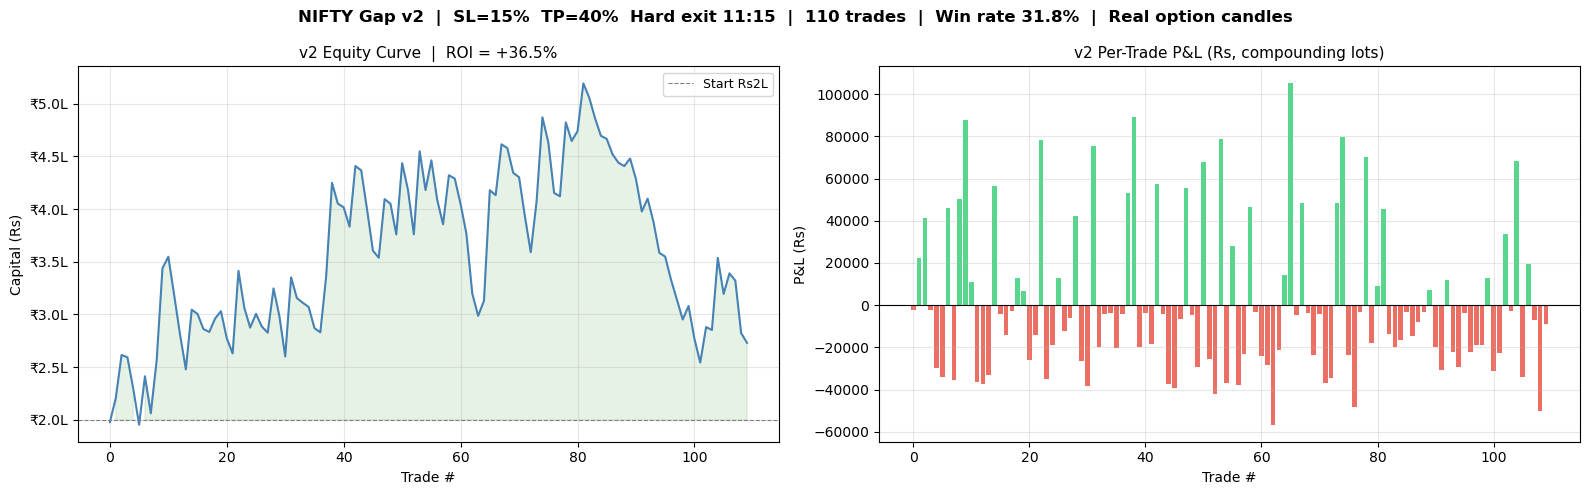

In [9]:
# ── Charts ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
x  = range(len(ledger))
ax.plot(x, ledger['Capital'], color='steelblue', lw=1.5)
ax.axhline(STARTING_CAPITAL, color='gray', ls='--', lw=0.8, label=f'Start Rs{STARTING_CAPITAL/1e5:.0f}L')
ax.fill_between(x, STARTING_CAPITAL, ledger['Capital'],
                where=ledger['Capital'] >= STARTING_CAPITAL, alpha=0.10, color='green')
ax.fill_between(x, STARTING_CAPITAL, ledger['Capital'],
                where=ledger['Capital'] <  STARTING_CAPITAL, alpha=0.10, color='red')
ax.set_title(f'v2 Equity Curve  |  ROI = {roi:+.1f}%', fontsize=11)
ax.set_xlabel('Trade #')
ax.set_ylabel('Capital (Rs)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'\u20b9{v/1e5:.1f}L'))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
colors = ['#2ecc71' if p > 0 else '#e74c3c' for p in ledger['Trade PnL']]
ax.bar(x, ledger['Trade PnL'], color=colors, alpha=0.8, width=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('v2 Per-Trade P&L (Rs, compounding lots)', fontsize=11)
ax.set_xlabel('Trade #')
ax.set_ylabel('P&L (Rs)')
ax.grid(True, alpha=0.3)

fig.suptitle(
    f'NIFTY Gap v2  |  SL={SL_PCT:.0%}  TP={TP_PCT:.0%}  Hard exit 11:15  |  '
    f'{total_r} trades  |  Win rate {wins_r / total_r * 100:.1f}%  |  Real option candles',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [10]:
# ── Trade log ─────────────────────────────────────────────────────────────────
pd.set_option('display.max_rows', 500)
pd.set_option('display.width', 200)
cols = ['Trade#', 'Date', 'DTE', 'Lots', 'Entry (pts)', 'Exit (pts)',
        'PnL (pts)', 'Charges', 'Trade PnL', 'Capital', 'Drawdown%',
        'Exit Reason', 'Actual', 'Correct?']
print(ledger[cols].to_string(index=False))

 Trade#       Date  DTE  Lots  Entry (pts)  Exit (pts)  PnL (pts)  Charges  Trade PnL   Capital  Drawdown% Exit Reason Actual Correct?
      1 2024-01-04    0    10        19.95       16.96      -2.99    72.94   -2315.44 197684.56       1.16   Stop Loss     UP       NO
      2 2024-01-05    6    25        82.10       94.30      12.20   369.57   22505.43 220189.99       0.00  11:15 exit     UP       NO
      3 2024-01-09    2    25        55.40       77.56      22.16   297.41   41252.59 261442.58       0.00  Target Hit     UP       NO
      4 2024-01-11    0    10        18.95       16.11      -2.84    71.65   -2201.65 259240.93       0.84   Stop Loss   DOWN      YES
      5 2024-01-12    6    25       105.05       89.29     -15.76   386.06  -29936.06 229304.87      12.29   Stop Loss     UP       NO
      6 2024-01-19    6    24       124.50      105.83     -18.67   432.76  -34038.76 195266.11      25.31   Stop Loss     UP       NO
      7 2024-01-23    2    25        61.70       86.38 